In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [4]:
conn = sqlite3.connect('/Users/tanimagarg/Downloads/data/inventory.db')
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.331591,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,24.0,599.76,449.82,0.52,27.08,-4840.24,-807.029478,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750.0,1,105.07,0.0,0.00,0.00,0.00,0.48,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.672675,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750.0,6,66.60,0.0,0.00,0.00,0.00,367.52,-66.60,0.000000,0.000000,0.000000


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


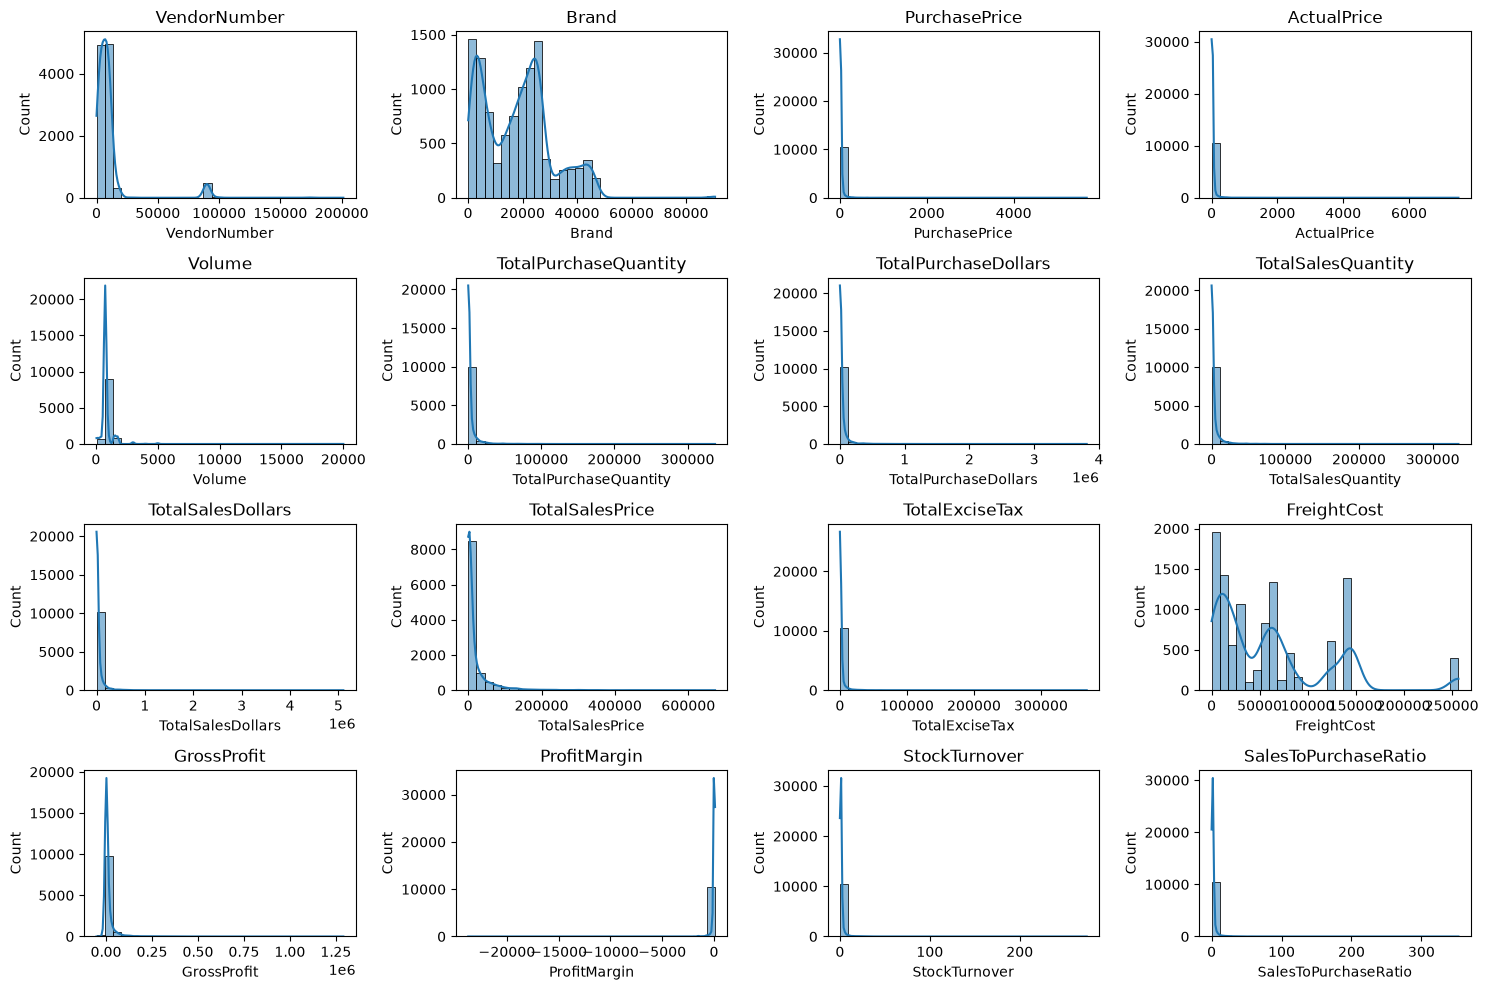

In [6]:
# Grab just the numeric columns
numerical_cols = df.select_dtypes(include='number').columns

# Draw a histogram for each, in a grid
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)      # 4x4 grid of mini-charts
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

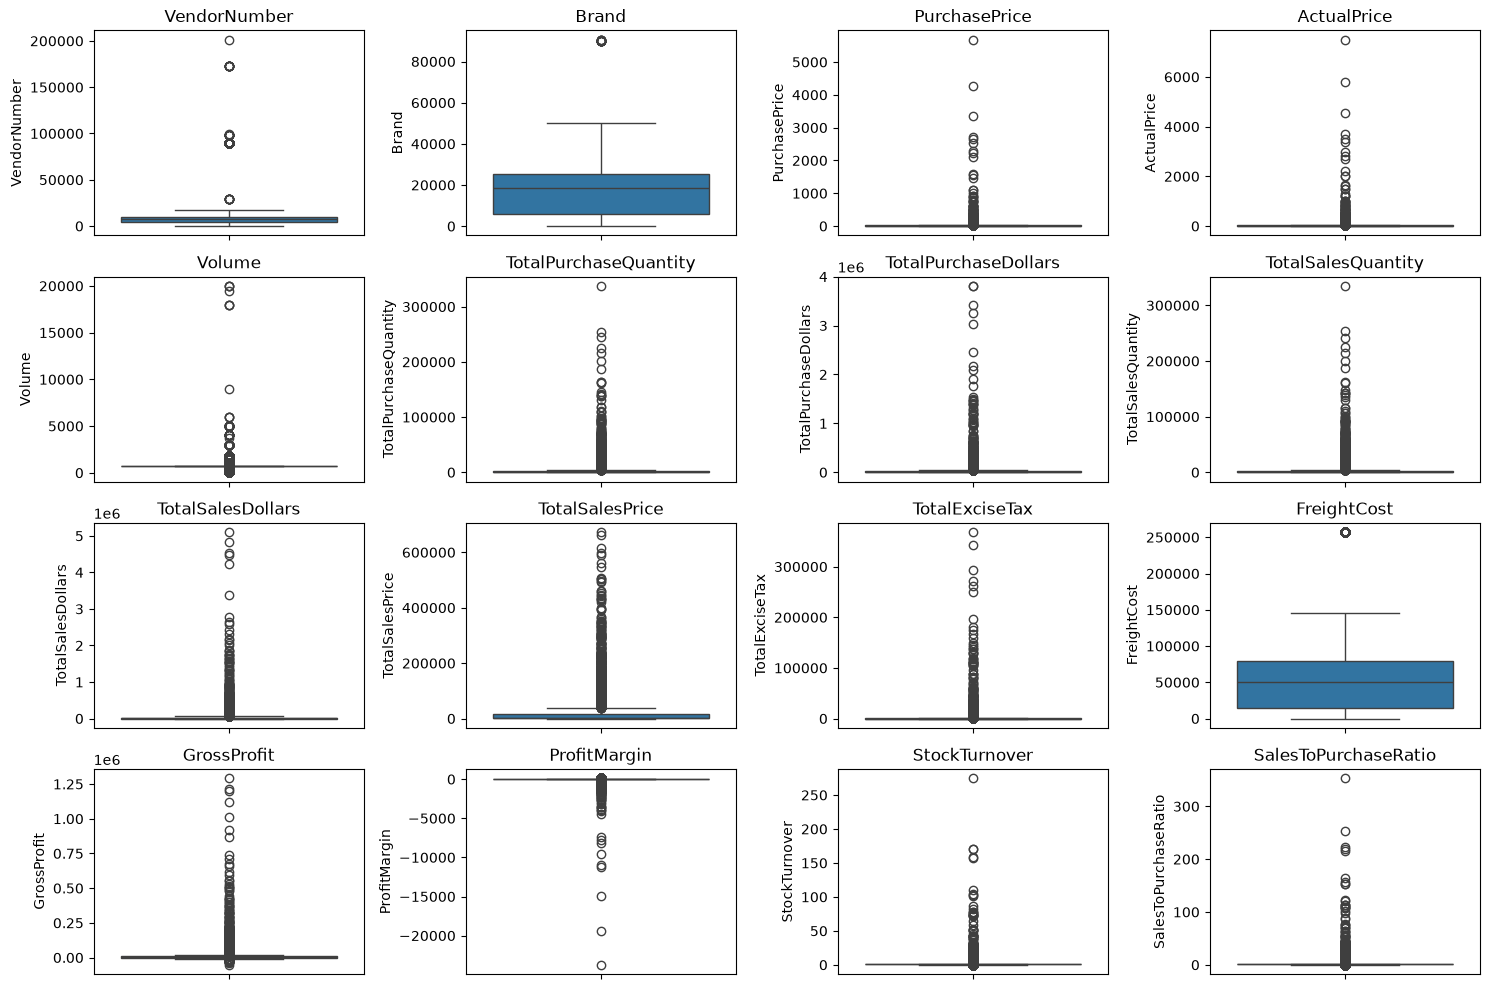

In [7]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis — Summary of Findings

**Dataset:** 10,692 vendor-brand rows | 126 vendors | fully cleaned (no missing values, no duplicates, correct dtypes).

### Key summary statistics

| Metric | Median (typical) | Mean | Max |
|--------|:---:|:---:|:---:|
| TotalPurchaseDollars | \$3,655 | \$30,107 | \$3.8M |
| TotalSalesDollars | \$5,298 | \$42,239 | \$5.1M |
| GrossProfit | \$1,400 | \$12,132 | \$1.29M |
| ProfitMargin % | 30.4% | −15.6% | 99.7% |
| StockTurnover | 0.98 | 1.71 | 274 |
| SalesToPurchaseRatio | 1.44 | 2.50 | 353 |

### Key observations
1. **Right-skewed data** — for sales/purchases/profit the max is ~1,000× the median, so a few mega-vendors dominate while most vendor-brands are small.
2. **Mean vs median diverge** — ProfitMargin mean is −15.6% but median is +30.4%; the typical product is healthily profitable, and the negative mean is caused by outliers. *Trust the median.*
3. **Extreme loss outliers** — ProfitMargin min −23,730%, GrossProfit min −\$52,003: a few products lose catastrophic amounts (over-bought, barely sold).
4. **Dead stock** — 178 brands were purchased but never sold (StockTurnover and TotalSalesDollars min = 0): frozen capital.
5. **Turnover concern** — median StockTurnover is 0.98; many vendor-brands sell only about what they bought, signalling slow-moving inventory.

### Implications for analysis
- Filter out never-sold / extreme-loss rows for margin analysis (use a `sales_df` working copy).
- Use the **median**, not the mean, for "typical" statements.
- Focus on top vendors for the Pareto (concentration) analysis.

In [8]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

print("Rows after filtering:", len(df))
df.head()


Rows after filtering: 8564


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.331591,2.250000,3.488160
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.672675,1.205128,1.579097
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12.0,359.88,59.98,9.44,62.39,80.88,22.474158,1.000000,1.289892
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,25.540808,0.959375,1.343018
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84.0,1511.16,287.84,9.43,6.19,577.08,38.187882,0.875000,1.617806


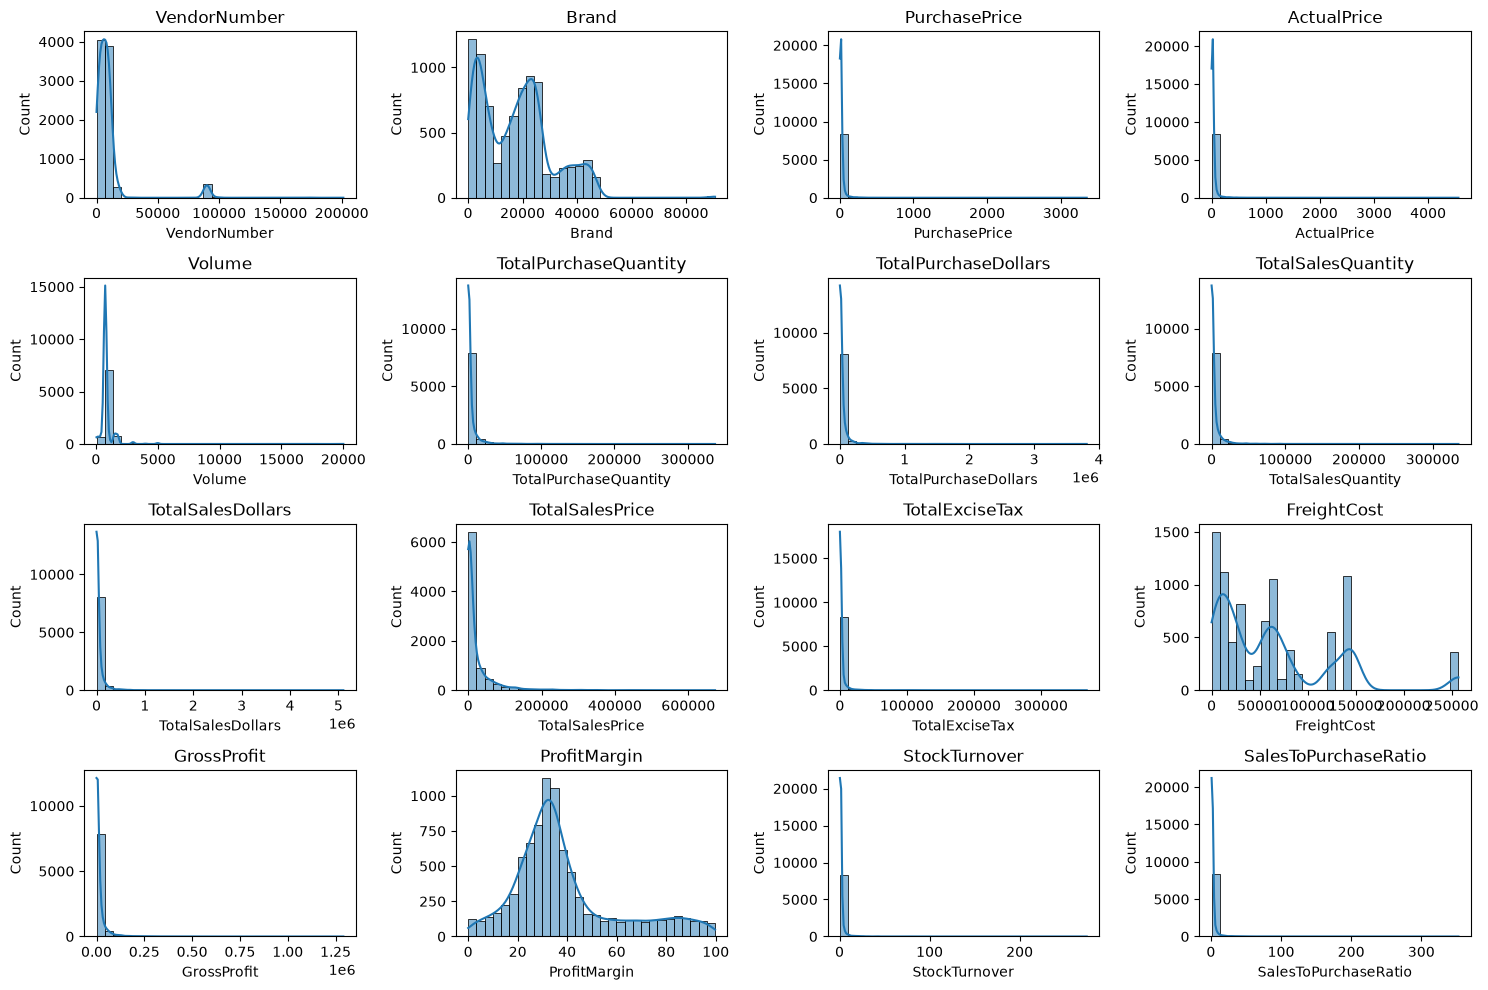

In [9]:
# Grab just the numeric columns
numerical_cols = df.select_dtypes(include='number').columns

# Draw a histogram for each, in a grid
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)      # 4x4 grid of mini-charts
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

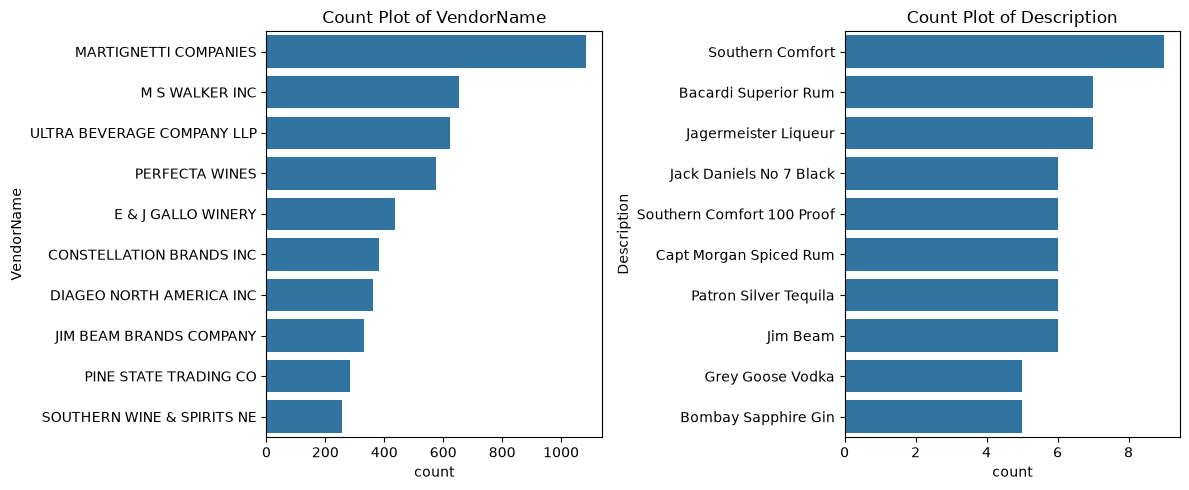

In [10]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])   # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

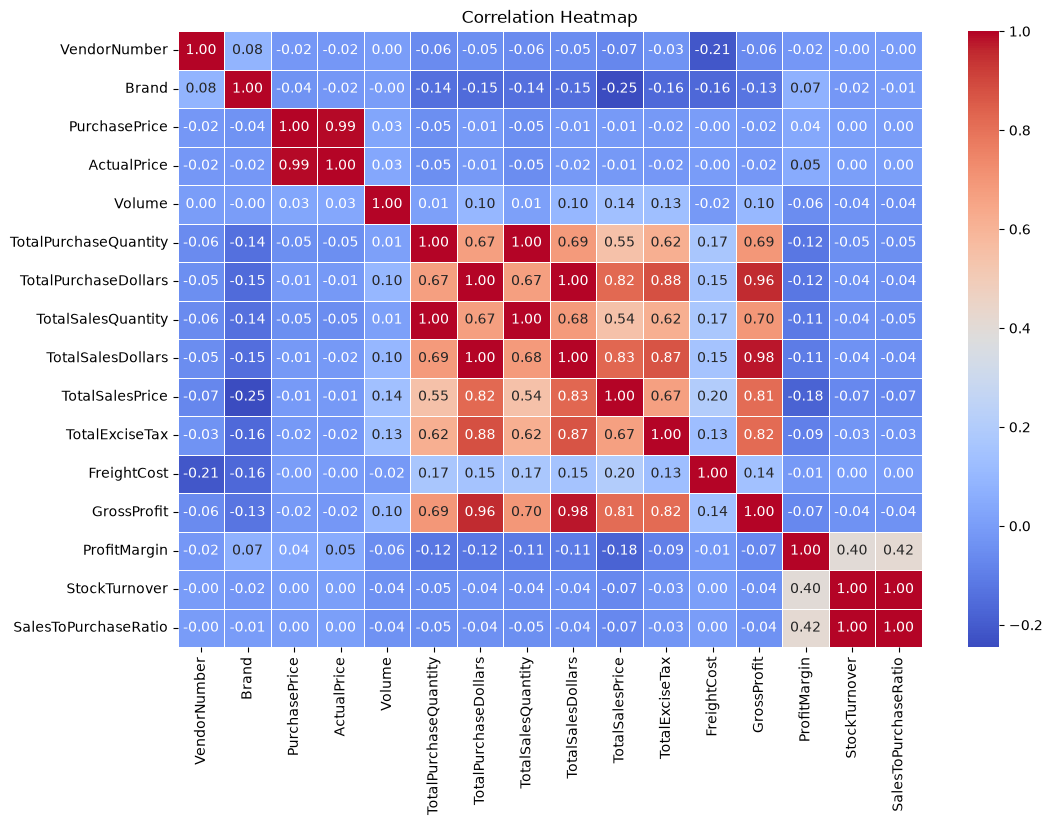

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Group to BRAND level: total sales + average margin per brand
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

# Define thresholds
low_sales_threshold  = brand_performance['TotalSalesDollars'].quantile(0.15)   # bottom 15% by sales
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)       # top 15% by margin

print("Low sales threshold (15th pct):", low_sales_threshold)
print("High margin threshold (85th pct):", high_margin_threshold)

Low sales threshold (15th pct): 560.299
High margin threshold (85th pct): 64.97017552750113


In [13]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with LOW sales but HIGH margin (promotion targets):", len(target_brands))
target_brands.sort_values('TotalSalesDollars').head(10)

Brands with LOW sales but HIGH margin (promotion targets): 198


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
4828,Merry Irish Cream Liqueur,35.97,73.533500
7184,Tracia Syrah,44.94,88.495772
600,Basilica Amaretto,47.45,85.079031
2934,Flag Hill Heritage Rd NH,49.96,65.532426
5124,New Amsterdam Red Berry Vdka,63.96,81.207004


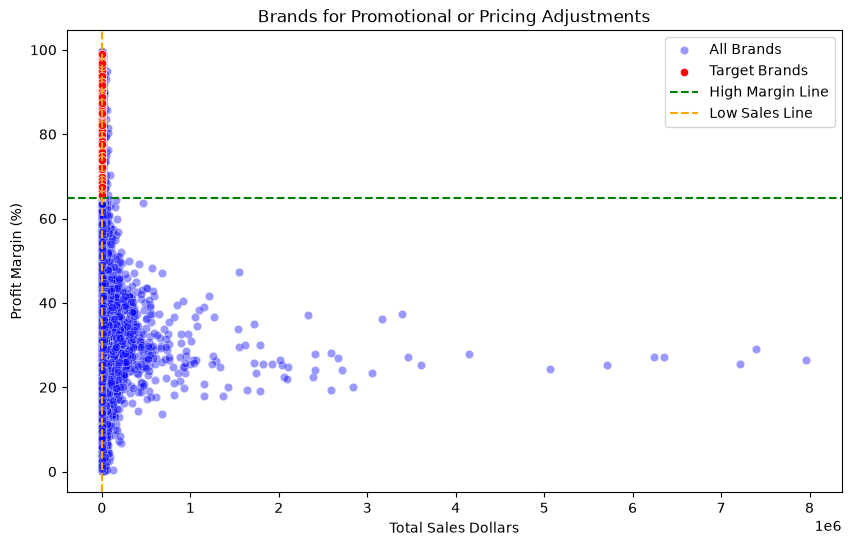

In [14]:
plt.figure(figsize=(10, 6))
# all brands in light blue
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',
                color='blue', label='All Brands', alpha=0.4)
# target brands highlighted in red
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',
                color='red', label='Target Brands')
# the threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='green', label='High Margin Line')
plt.axvline(low_sales_threshold, linestyle='--', color='orange', label='Low Sales Line')

plt.xlabel("Total Sales Dollars")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.show()

In [15]:
# Group to vendor level: total sales + total profit per vendor
top_vendors = df.groupby('VendorName').agg({
    'TotalSalesDollars': 'sum',
    'GrossProfit': 'sum'
}).sort_values('TotalSalesDollars', ascending=False).head(10)

top_vendors


,TotalSalesDollars,GrossProfit
VendorName,,
DIAGEO NORTH AMERICA INC,67990099.42,17892873.26
MARTIGNETTI COMPANIES,39330359.36,13828263.53
PERNOD RICARD USA,32063196.19,8212032.02
JIM BEAM BRANDS COMPANY,31423020.46,7928716.14
BACARDI USA INC,24854817.14,7422796.88
CONSTELLATION BRANDS INC,24218745.65,8945037.57
E & J GALLO WINERY,18399899.46,6331360.24
BROWN-FORMAN CORP,18247230.65,5008291.47
ULTRA BEVERAGE COMPANY LLP,16502544.31,5335462.70


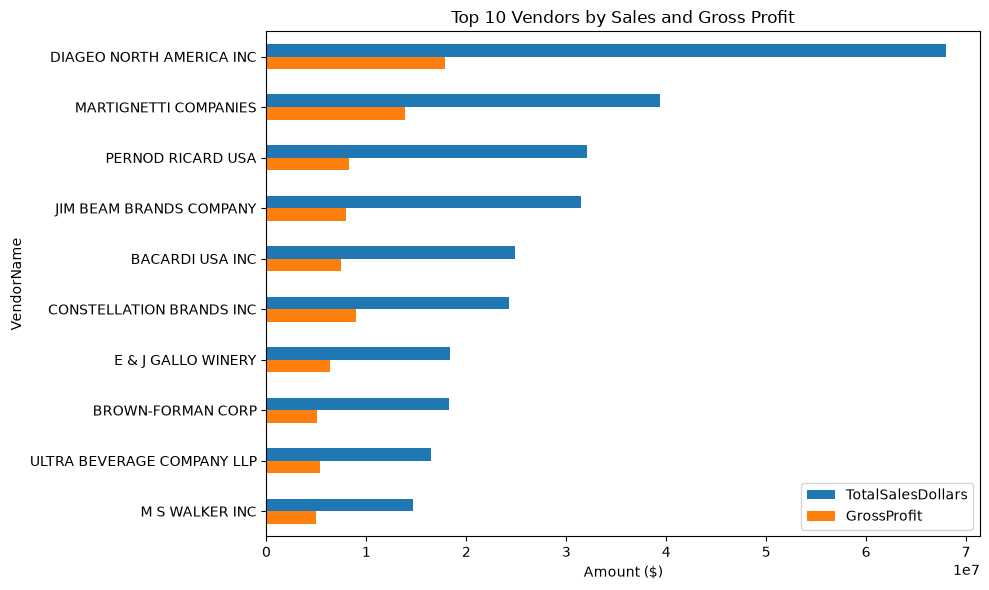

In [16]:
top_vendors[['TotalSalesDollars', 'GrossProfit']].plot(
    kind='barh', figsize=(10, 6))
plt.xlabel("Amount ($)")
plt.title("Top 10 Vendors by Sales and Gross Profit")
plt.gca().invert_yaxis()          # biggest vendor on top
plt.tight_layout()
plt.show()

Top 10 vendors = 65.7% of total purchase spend
Total vendors: 119


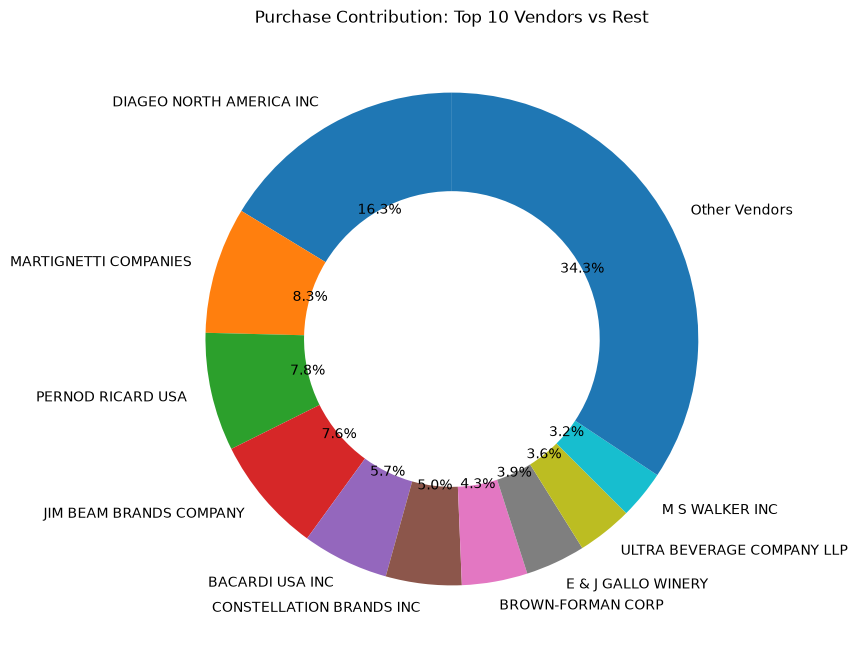

In [17]:
# Total PURCHASES per vendor, ranked
vendor_purchase = df.groupby('VendorName')['TotalPurchaseDollars'].sum().sort_values(ascending=False)

# What share do the top 10 vendors control?
top10_share = vendor_purchase.head(10).sum() / vendor_purchase.sum() * 100
print(f"Top 10 vendors = {top10_share:.1f}% of total purchase spend")
print(f"Total vendors: {len(vendor_purchase)}")

# Donut chart: top 10 vs everyone else
top10 = vendor_purchase.head(10)
others = pd.Series({'Other Vendors': vendor_purchase.iloc[10:].sum()})
combined = pd.concat([top10, others])

plt.figure(figsize=(8, 8))
plt.pie(combined, labels=combined.index, autopct='%1.1f%%', startangle=90,
        wedgeprops={'width': 0.4})     # width<1 makes it a donut
plt.title("Purchase Contribution: Top 10 Vendors vs Rest")
plt.show()

In [18]:
# Cost per single unit = total spent ÷ total units bought
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [19]:
# Split into 3 equal-sized groups by how much they purchased
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

# Average unit cost per group
df.groupby('OrderSize')['UnitPurchasePrice'].mean()

OrderSize
Small     39.068186
Medium    15.486414
Large     10.777625
Name: UnitPurchasePrice, dtype: float64

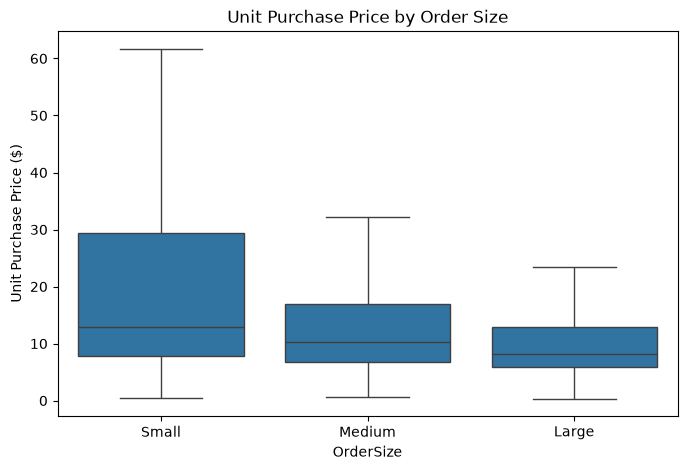

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='OrderSize', y='UnitPurchasePrice', data=df, showfliers=False)
plt.title("Unit Purchase Price by Order Size")
plt.ylabel("Unit Purchase Price ($)")
plt.show()

In [21]:
# Reload ALL rows (including dead stock) — this question is ABOUT unsold inventory
df_all = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
print("Full data:", df_all.shape)

Full data: (10692, 18)


In [22]:
# Value of stock we BOUGHT but didn't SELL = leftover units × what we paid per unit
df_all['UnsoldInventoryValue'] = (
    (df_all['TotalPurchaseQuantity'] - df_all['TotalSalesQuantity']) * df_all['PurchasePrice']
).clip(lower=0)     # clip: ignore cases where they sold more than bought (drew down old stock)

total_locked = df_all['UnsoldInventoryValue'].sum()
print(f"Total capital locked in unsold inventory: ${total_locked:,.0f}")

Total capital locked in unsold inventory: $15,600,727


In [23]:
unsold_by_vendor = (df_all.groupby('VendorName')['UnsoldInventoryValue']
                    .sum().sort_values(ascending=False).head(10))
print(unsold_by_vendor)

VendorName
MARTIGNETTI COMPANIES         1928345.65
DIAGEO NORTH AMERICA INC      1656475.58
ULTRA BEVERAGE COMPANY LLP    1475999.28
JIM BEAM BRANDS COMPANY       1136390.67
PERFECTA WINES                 915643.81
M S WALKER INC                 850048.16
PERNOD RICARD USA              723100.01
WILLIAM GRANT & SONS INC       502617.82
E & J GALLO WINERY             486888.76
CONSTELLATION BRANDS INC       448592.84
Name: UnsoldInventoryValue, dtype: float64


In [24]:
import numpy as np

# Define the two groups by sales performance
top_threshold = df['TotalSalesDollars'].quantile(0.75)   # top 25% sellers
low_threshold = df['TotalSalesDollars'].quantile(0.25)   # bottom 25% sellers

top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin']
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin']

# 95% confidence interval for each group's mean margin
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err  = stats.sem(data)                                   # standard error
    margin   = std_err * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean_val, mean_val - margin, mean_val + margin

top_mean, top_lo, top_hi = confidence_interval(top_vendors)
low_mean, low_lo, low_hi = confidence_interval(low_vendors)

print(f"Top vendors  — mean margin {top_mean:.2f}%, 95% CI ({top_lo:.2f}, {top_hi:.2f})")
print(f"Low vendors  — mean margin {low_mean:.2f}%, 95% CI ({low_lo:.2f}, {low_hi:.2f})")

# The t-test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)
print(f"\nT-statistic: {t_stat:.4f}   P-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Reject H0: the margins ARE significantly different.")
else:
    print("=> Fail to reject H0: no significant difference.")

Top vendors  — mean margin 31.18%, 95% CI (30.74, 31.61)
Low vendors  — mean margin 41.57%, 95% CI (40.50, 42.64)

T-statistic: -17.6695   P-value: 0.0000
=> Reject H0: the margins ARE significantly different.


## Hypothesis Testing: Do High- and Low-Performing Vendors Differ in Profit Margin?

**Goal:** Statistically test whether the observed margin gap between high-sales and
low-sales vendors is real, or just random chance.

**Setup**
- **Groups:** Top 25% of vendors by `TotalSalesDollars` vs. Bottom 25%.
- **Metric:** `ProfitMargin`.
- **H0 (null):** the two groups have the *same* mean profit margin.
- **H1 (alternative):** the two groups have *different* mean profit margins.
- **Significance level (α):** 0.05.
- **Test:** Welch's two-sample t-test (does not assume equal variance).

**Results**

| Group | Mean Margin | 95% Confidence Interval |
|-------|:---:|:---:|
| Top vendors (high sales) | 31.18% | (30.74, 31.61) |
| Low vendors (low sales) | 41.57% | (40.50, 42.64) |

- **T-statistic:** −17.67
- **P-value:** < 0.001

**Interpretation**
- p-value < 0.05 → **reject H0**: the difference in margins is statistically significant.
- The 95% confidence intervals do **not overlap**, reinforcing that the two groups are
  genuinely different populations.
- **Low-volume vendors earn significantly higher margins (41.6%)** than high-volume
  vendors (31.2%).

**Business meaning**
Two distinct vendor models exist: high-volume vendors compete on price (thin margins, high
total profit), while low-volume vendors are premium/niche (high margins, low total dollars).
Low-volume vendors should not be treated as underperformers — they are the most
margin-efficient suppliers and prime targets for volume-growth promotions.

In [25]:
%run get_vendor_summary.py

Exception: File `'get_vendor_summary.py'` not found.